# **Entrenamiento, Optimización de Hiperparámetros, Evaluación y Reporte de Métricas**

In [1]:
# Librerías 

import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings
import pickle
from tqdm import tqdm

from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.metrics import (accuracy_score, precision_score, recall_score, roc_auc_score,
                             average_precision_score, f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve, brier_score_loss, log_loss)
from sklearn.model_selection import (cross_val_score, StratifiedKFold, learning_curve, train_test_split)
from sklearn.calibration import calibration_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

c:\Users\ADMIN\Desktop\U\Semestre 7\Ciencia de Datos en Producción\Financial_Risk_pipeline\env_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cargar Environment

pth = Path(os.getenv("DATA_FILE"))

# Cargar Data

df = pd.read_excel(pth / "BD_creditos_procesado.xlsx")

In [3]:
# -------------------------------------------------------------------------------------------------
# 1. CONFIGURACIÓN GLOBAL Y DIVISIÓN DE DATOS
# -------------------------------------------------------------------------------------------------


# Se hace Oversampling con SMOTE de 33%, Stratified KFold con 5 folds
# Partición de datos (80% para train y 20% para test)
# Variable target --> Pago_atiempo

SMOTE_RATIO = 0.33
cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
resultados_modelos = {}


def data_division(data: pd.DataFrame, test_size: float, target_column: str = "Pago_atiempo"):

    X = data.drop(columns=[target_column])
    y = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, random_state = 42, stratify = y)
    
    return X_train, X_test, y_train, y_test

In [4]:
# División de Datos

X_train, X_test, y_train, y_test = data_division(df, 0.2)

# Script de Hiperparametrización, Evaluación y Métricas Básicas **sin SMOTE**

In [5]:
# ---------------------------------------- AJUSTE DE HIPERPARÁMETROS SIN SMOTE ----------------------------------------------------


# ---------------------------------------- Tuning Regresión Logística  ------------------------------------------------------------


def logistic_regression_tuning(trial, cv = cv_strategy, metric: str = "f1_macro"):

    solver = trial.suggest_categorical("solver", ["lbfgs", "liblinear", "saga"])
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    C = trial.suggest_float("C", 1e-4, 10, log = True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    if penalty == "elasticnet":

        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    else:

        l1_ratio = None

    if solver == "lbfgs" and penalty != "l2":

        return 0.0
    
    if solver == "liblinear" and penalty == "elasticnet":

        return 0.0
    
    if solver != "saga" and penalty == "elasticnet":

        return 0.0

    model = LogisticRegression(solver = solver, penalty = penalty, C = C, class_weight = class_weight,l1_ratio = l1_ratio)
    
    return cross_val_score(model, X_train, y_train, cv = cv, scoring = metric).mean()


# ---------------------------------------- Tuning Árbol de Decisión ------------------------------------------------------------------------------------

def decision_tree_tuning(trial, cv = cv_strategy, metric: str = "f1_macro"):

     model = DecisionTreeClassifier(
        max_depth = trial.suggest_int("max_depth", 2, 7),
        min_samples_split = trial.suggest_int("min_samples_split", 10, 50),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 20),
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy"]),
        random_state = 42,
        class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    )

     return cross_val_score(model, X_train, y_train, cv = cv, scoring = metric).mean()


# ---------------------------------------- Tuning Random Forest ------------------------------------------------------------------------------------

def random_forest_tuning(trial, cv = cv_strategy, metric: str = "f1_macro"):

    model = RandomForestClassifier(
        n_estimators = trial.suggest_int("n_estimators", 50, 150),
        max_depth = trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 30),
        min_samples_split = trial.suggest_int("min_samples_split", 10, 50),
        random_state = 42, n_jobs = -1,
        class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    )
    return cross_val_score(model, X_train, y_train, cv = cv, scoring = metric).mean()


# ---------------------------------------- Tuning Light GBM ------------------------------------------------------------------------------------

def lightGBM_tuning(trial, cv = cv_strategy, metric: str = "f1_macro"):
    
    model = LGBMClassifier(
        n_estimators = trial.suggest_int("n_estimators", 50, 150),
        max_depth = trial.suggest_int("max_depth", 2, 7),
        learning_rate = trial.suggest_float("learning_rate", 1e-3, 1e-1, log = True),
        num_leaves = trial.suggest_int("num_leaves", 10, 30),
        subsample = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        random_state = 42, n_jobs=-1, verbosity = -1
    )

    return cross_val_score(model, X_train, y_train, cv = cv, scoring = metric).mean()


# ---------------------------------------- Tuning SVM ------------------------------------------------------------------------------------

def svm_tuning(trial, cv = cv_strategy, metric: str = "f1_macro"):

    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'sigmoid'])
    gamma = trial.suggest_float('gamma', 1e-3, 1e-1, log = True)
    model = SVC(kernel = kernel, gamma = gamma)

    return cross_val_score(model, X_train, y_train, cv = cv, scoring = metric).mean()


# ---------------------------------------- Tuning XGBoost  ------------------------------------------------------------------------------------

def xgboost_tuning(trial, cv = cv_strategy, metric: str = "f1_macro"):
    
    model = XGBClassifier(
        n_estimators = trial.suggest_int("n_estimators", 50, 150),
        max_depth = trial.suggest_int("max_depth", 2, 7),
        learning_rate = trial.suggest_float("learning_rate", 1e-3, 1e-1, log = True),
        subsample = trial.suggest_float("subsample", 0.5, 1.0),
        eval_metric = 'logloss',random_state = 42,n_jobs = -1
    )

    return cross_val_score(model, X_train, y_train, cv = cv, scoring = metric).mean()




# ---------------------------------------- HIPERPARAMETRIZACIÓN COMPLETA  ------------------------------------------------------------------------------------

modelos_clasificadores = {
    'Logistic Regression': (logistic_regression_tuning, LogisticRegression),
    'Decision Tree': (decision_tree_tuning, DecisionTreeClassifier),
    'SVM': (svm_tuning, SVC),
    'Random Forest': (random_forest_tuning, RandomForestClassifier),
    'XGBoost': (xgboost_tuning, XGBClassifier),
    'LightGBM': (lightGBM_tuning, LGBMClassifier),

}


for name, (objective, constructor) in modelos_clasificadores.items():

    print("------------------------------------------------------------------------------------------------")
    print("Optimizating WITHOUT SMOTE", name, " ...")
    print("------------------------------------------------------------------------------------------------")
    print("------------------------------------------------------------------------------------------------")

    study = optuna.create_study(direction = 'maximize')
    study.optimize(objective, n_trials = 10)

    print(f"Mejor F1 de los trials SIN SMOTE: {round(study.best_value, 3)}")
    print(f"Hiperparámetros SIN SMOTE: {study.best_params}")

    # Train the model with the best hyperparameter fit
  
    final_model = constructor(**study.best_params)


    # Fit the model

    final_model.fit(X_train, y_train)

    # F1 Macro

    y_train_pred = final_model.predict(X_train)
    train_f1_macro = f1_score(y_train, y_train_pred, average = "macro")

    print(f"Train F1 macro SIN SMOTE: {round(train_f1_macro, 3)}")

    # Ver comportamiento en el test

    y_test_pred = final_model.predict(X_test)
    test_f1_macro = f1_score(y_test, y_test_pred, average = "macro")

    print(f"Test F1 macro SIN SMOTE: {round(test_f1_macro, 3)}")
    
    print("Classification Report sobre Test SIN SMOTE")
    print(classification_report(y_test, final_model.predict(X_test)))

    # Guardar resultados

    resultados_modelos[name] = {
        'model': final_model,
        'parameters': study.best_params,
        'train_f1_model': train_f1_macro,
        'test_f1_model': test_f1_macro,
        'study': study
    }

------------------------------------------------------------------------------------------------
Optimizating WITHOUT SMOTE Logistic Regression  ...
------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------
Mejor F1 de los trials SIN SMOTE: 0.505
Hiperparámetros SIN SMOTE: {'solver': 'saga', 'penalty': 'l1', 'C': 2.024435896938106, 'class_weight': None}
Train F1 macro SIN SMOTE: 0.505
Test F1 macro SIN SMOTE: 0.507
Classification Report sobre Test SIN SMOTE
              precision    recall  f1-score   support

           0       0.50      0.02      0.04       100
           1       0.95      1.00      0.98      2021

    accuracy                           0.95      2121
   macro avg       0.73      0.51      0.51      2121
weighted avg       0.93      0.95      0.93      2121

---------------------------------------------------------------------------

# Script Completo **con SMOTE** 

In [6]:
# -------------------------------------------------------------------------------------------------
# 2. FUNCIONES DE EVALUACIÓN PROFUNDA
# -------------------------------------------------------------------------------------------------



# Función de validación cruzada con métricas específicas para cada clase evaluando el pipeline completo

def crossval_detailed_metrics(pipeline_estimator, X_train, y_train, cv = 5):

    skf = StratifiedKFold(n_splits = cv, shuffle = True, random_state = 42)

    metricas_por_fold = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):

        # Puede hacerse con Dataframes de pandas o arrays de numpy

        if isinstance(X_train, pd.DataFrame):

            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        else:

            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # Clonar el pipeline para asegurar que empieza limpio en cada fold

        model_fold = clone(pipeline_estimator)
        model_fold.fit(X_tr, y_tr)

        y_pred = model_fold.predict(X_val)

        # Calcular métricas del fold

        fold_metricas = {
            'fold': fold + 1,
            'f1_macro': f1_score(y_val, y_pred, average = "macro"),
            'precision_0': precision_score(y_val, y_pred, pos_label = 0, zero_division = 0),
            'recall_0': recall_score(y_val, y_pred, pos_label = 0, zero_division = 0),
            'f1_0': f1_score(y_val, y_pred, pos_label = 0, zero_division = 0),
            'precision_1': precision_score(y_val, y_pred, pos_label = 1, zero_division = 0),
            'recall_1': recall_score(y_val, y_pred, pos_label = 1, zero_division = 0),
            'f1_1': f1_score(y_val, y_pred, pos_label = 1, zero_division = 0)
        }
        metricas_por_fold.append(fold_metricas)

    cv_results = pd.DataFrame(metricas_por_fold)

    print(f"\nRESUMEN VALIDACIÓN CRUZADA (Train)")
    print("-" * 60)

    for metrica in ['f1_macro', 'recall_0', 'precision_0', 'f1_0', 'recall_1', 'precision_1', 'f1_1']:

        valor = cv_results[metrica]

        print(f"{metrica:15}: {valor.mean():.4f} ± {valor.std():.4f}")

    return cv_results



# Función de visualización --> Curvas de Aprendizaje, Escalabilidad y Gap de Rendimiento

def plot_learning_curves(estimator, X, y, scoring = "f1_macro", model_name = "Model"):

    print(f"\nGenerando curvas de aprendizaje para {model_name}...")

    train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
        estimator = estimator, 
        X = X, y = y,
        train_sizes = np.linspace(0.1, 1.0, 5),
        cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42),
        n_jobs = -1, scoring = scoring, return_times = True
    )

    train_mean, train_std = train_scores.mean(axis = 1), train_scores.std(axis = 1)
    test_mean, test_std = test_scores.mean(axis = 1), test_scores.std(axis = 1)
    fit_times_mean, fit_times_std = fit_times.mean(axis = 1), fit_times.std(axis = 1)
    score_times_mean, score_times_std = score_times.mean(axis = 1), score_times.std(axis = 1)

    # Generar subplots

    fig, axes = plt.subplots(2, 2, figsize = (15, 10))

    fig.suptitle(f'Análisis de Curvas de Aprendizaje - {model_name}', fontsize = 16)


    # 1. Curva principal

    axes[0, 0].plot(train_sizes, train_mean, "o-", label = "Entrenamiento", color = 'blue')
    axes[0, 0].plot(train_sizes, test_mean,  "o-", label = "Validación (CV)", color = 'red')
    axes[0, 0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha = 0.1, color = 'blue')
    axes[0, 0].fill_between(train_sizes, test_mean  - test_std,  test_mean  + test_std,  alpha = 0.1, color = 'red')
    axes[0, 0].set_title(f"Curva de aprendizaje ({scoring})")
    axes[0, 0].set_xlabel("Ejemplos de entrenamiento")
    axes[0, 0].set_ylabel(scoring.upper())
    axes[0, 0].legend(loc = "best")
    axes[0, 0].grid(True, alpha = 0.3)


    # 2. Tiempo de entrenamiento

    axes[0, 1].plot(train_sizes, fit_times_mean, "o-", color = 'springgreen')
    axes[0, 1].fill_between(train_sizes, fit_times_mean - fit_times_std, fit_times_mean + fit_times_std, alpha = 0.1, color = 'green')
    axes[0, 1].set_title("Escalabilidad (Tiempo de Entrenamiento)")
    axes[0, 1].set_xlabel("Ejemplos de entrenamiento")
    axes[0, 1].set_ylabel("Tiempo (seg)")
    axes[0, 1].grid(True, alpha = 0.3)


    # 3. Tiempo de predicción

    axes[1, 0].plot(train_sizes, score_times_mean, "o-", color = 'orangered')
    axes[1, 0].fill_between(train_sizes, score_times_mean - score_times_std, score_times_mean + score_times_std, alpha = 0.1, color = 'orange')
    axes[1, 0].set_title("Eficiencia (Tiempo de Predicción)")
    axes[1, 0].set_xlabel("Ejemplos de entrenamiento")
    axes[1, 0].set_ylabel("Tiempo (seg)")
    axes[1, 0].grid(True, alpha = 0.3)


    # 4. Gap (Overfitting)

    gap = train_mean - test_mean
    axes[1, 1].plot(train_sizes, gap, "o-", color = 'darkviolet')
    axes[1, 1].axhline(y = 0, color = 'black', linestyle = '--', alpha = 0.5)
    axes[1, 1].set_title("Gap Entrenamiento-Validación (Overfitting)")
    axes[1, 1].set_xlabel("Ejemplos de entrenamiento")
    axes[1, 1].set_ylabel(f"Diferencia {scoring}")
    axes[1, 1].grid(True, alpha = 0.3)

    plt.tight_layout()
    plt.show()



# Función de visualización de gráficos avanzados --> ROC, PRC, Calibración, Matriz de Confusión Normalizada

def plot_advanced_evaluation(pipeline_model, X_test, y_test, model_name = "Model"):

    print(f"\nGenerando dashboard para {model_name}...")

    y_proba = pipeline_model.predict_proba(X_test)[:, 1]
    y_pred = pipeline_model.predict(X_test)

    # Cálculo de métricas

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

    # Imprimir métricas probabilísticas

    print("\nMÉTRICAS PROBABILÍSTICAS (TEST)")
    print("-" * 40)
    print(f"ROC-AUC        : {roc_auc_val:.4f}")
    print(f"PR-AUC         : {pr_auc:.4f}")
    print(f"Brier Score    : {brier_score_loss(y_test, y_proba):.4f}")
    print(f"Log Loss       : {log_loss(y_test, y_proba):.4f}")

    # Plot Dashboard 2x2

    fig, axes = plt.subplots(2, 2, figsize = (14, 12))

    fig.suptitle(f'Dashboard Avanzado de Evaluación - {model_name}', fontsize = 16, y = 0.98)


    # 1. ROC Curve

    axes[0, 0].plot(fpr, tpr, label = f"ROC curve (AUC = {roc_auc_val:.4f})", color = 'darkred', lw = 2)
    axes[0, 0].plot([0, 1], [0, 1], linestyle = "--", color = 'navy')
    axes[0, 0].set_xlabel("False Positive Rate")
    axes[0, 0].set_ylabel("True Positive Rate")
    axes[0, 0].set_title("Curva ROC")
    axes[0, 0].legend(loc = "lower right")
    axes[0, 0].grid(alpha = 0.3)


    # 2. Precision-Recall Curve

    axes[0, 1].plot(recall, precision, label = f"PR curve (AUC = {pr_auc:.4f})", color = 'royalblue', lw = 2)
    axes[0, 1].set_xlabel("Recall")
    axes[0, 1].set_ylabel("Precision")
    axes[0, 1].set_title("Curva Precision-Recall")
    axes[0, 1].legend(loc = "lower left")
    axes[0, 1].grid(alpha = 0.3)


    # 3. Curva de Calibración

    axes[1, 0].plot(prob_pred, prob_true, "s-", label = f"{model_name}", color = 'limegreen')
    axes[1, 0].plot([0, 1], [0, 1], "k:", label = "Perfectamente calibrado")
    axes[1, 0].set_xlabel("Probabilidad Media Predicha")
    axes[1, 0].set_ylabel("Fracción de Positivos Reales")
    axes[1, 0].set_title("Curva de Calibración (Reliability)")
    axes[1, 0].legend(loc = "lower right")
    axes[1, 0].grid(alpha = 0.3)


    # 4. Matriz de Confusión Normalizada

    sns.heatmap(cm, annot = True, fmt = ".2f", cmap = "viridis",
                xticklabels = ["No Pago", "Pago"], yticklabels = ["No Pago", "Pago"], ax = axes[1, 1])
    axes[1, 1].set_title("Matriz de Confusión (Normalizada por Fila)")
    axes[1, 1].set_ylabel("Clase Real")
    axes[1, 1].set_xlabel("Predicción")

    plt.tight_layout(rect = [0, 0, 1, 0.96])
    plt.show()



# Funcipon de Entrenamiento Model Final y análsiis de Estabilidad

def evaluate_and_analyze(pipeline_model, X_train, y_train, X_test, y_test, model_name = "Model"):

    print(f"\n{'='*60}")
    print(f"EVALUACIÓN Y ANÁLISIS: {model_name.upper()}")
    print(f"{'='*60}")

    # 1. Validación Cruzada Detallada

    cv_results = crossval_detailed_metrics(pipeline_model, X_train, y_train, cv = 5)

    # 2. Entrenar modelo final con todo el Train
    
    pipeline_model.fit(X_train, y_train)

    # 3. Predecir en Test

    y_test_pred = pipeline_model.predict(X_test)
    test_f1_macro = f1_score(y_test, y_test_pred, average = "macro")
    test_recall_0 = recall_score(y_test, y_test_pred, pos_label = 0, zero_division = 0)

    # 4. Reporte de Clasificación sobre Test

    print(f"\n=== CLASSIFICATION REPORT SOBRE TEST ===")
    print(classification_report(y_test, y_test_pred, target_names = ['No Pago (0)', 'Pago (1)']))

    # 5. Análisis de Estabilidad (Test vs Validación Cruzada)

    cv_f1_macro_mean = cv_results['f1_macro'].mean()
    f1_diff = abs(test_f1_macro - cv_f1_macro_mean)

    print(f"ANÁLISIS DE ESTABILIDAD (F1-Macro):")
    print(f"• Rendimiento esperado (CV):   {cv_f1_macro_mean:.4f}")
    print(f"• Rendimiento real (Test):     {test_f1_macro:.4f}")
    print(f"• Diferencia (Over/Under-fit): {f1_diff:.4f}")

    if f1_diff < 0.05:

        print("-> Modelo MUY ESTABLE y confiable.")

    elif f1_diff < 0.10:

        print("-> Diagnóstico: Modelo MODERADAMENTE estable.")

    else:

        print("-> Diagnóstico: Modelo INESTABLE y no confiable")


    return cv_results, test_f1_macro

In [7]:
# -------------------------------------------------------------------------------------------------
# 3. FUNCIONES DE AJUSTE DE HIPERPARÁMETROS (CON SMOTE INCLUIDO)
# -------------------------------------------------------------------------------------------------


# Regresión Logística

def logistic_regression_tuning(trial, cv = cv_strategy, metric = "f1_macro"):

    solver = trial.suggest_categorical("solver", ["lbfgs", "liblinear", "saga"])
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    C = trial.suggest_float("C", 1e-4, 10, log = True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0) if penalty == "elasticnet" else None

    if solver == "lbfgs" and penalty != "l2": return 0.0
    if solver == "liblinear" and penalty == "elasticnet": return 0.0
    if solver != "saga" and penalty == "elasticnet": return 0.0

    model = LogisticRegression(solver = solver, penalty = penalty, C = C, class_weight = class_weight, l1_ratio = l1_ratio)
    pipeline = Pipeline(steps = [('smote', SMOTE(sampling_strategy = SMOTE_RATIO, random_state = 42)), ('model', model)])
    
    return cross_val_score(pipeline, X_train, y_train, cv = cv, scoring = metric).mean()


# Árbol de Decisión

def decision_tree_tuning(trial, cv = cv_strategy, metric = "f1_macro"):

    model = DecisionTreeClassifier(
        max_depth = trial.suggest_int("max_depth", 2, 7),
        min_samples_split = trial.suggest_int("min_samples_split", 10, 50),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 20),
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy"]),
        random_state = 42, class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    )

    pipeline = Pipeline(steps = [('smote', SMOTE(sampling_strategy = SMOTE_RATIO, random_state = 42)), ('model', model)])
    
    return cross_val_score(pipeline, X_train, y_train, cv = cv, scoring = metric).mean()


# Random Forest

def random_forest_tuning(trial, cv = cv_strategy, metric = "f1_macro"):

    model = RandomForestClassifier(
        n_estimators = trial.suggest_int("n_estimators", 50, 150),
        max_depth = trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 30),
        min_samples_split = trial.suggest_int("min_samples_split", 10, 50),
        random_state = 42, n_jobs = -1, class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    )
    pipeline = Pipeline(steps = [('smote', SMOTE(sampling_strategy = SMOTE_RATIO, random_state = 42)), ('model', model)])

    return cross_val_score(pipeline, X_train, y_train, cv = cv, scoring = metric).mean()


# LightGBM

def lightGBM_tuning(trial, cv = cv_strategy, metric = "f1_macro"):

    model = LGBMClassifier(
        n_estimators = trial.suggest_int("n_estimators", 50, 150),
        max_depth = trial.suggest_int("max_depth", 2, 7),
        learning_rate = trial.suggest_float("learning_rate", 1e-3, 1e-1, log = True),
        num_leaves = trial.suggest_int("num_leaves", 10, 30),
        subsample = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        random_state = 42, n_jobs = -1, verbosity = -1
    )

    pipeline = Pipeline(steps = [('smote', SMOTE(sampling_strategy = SMOTE_RATIO, random_state = 42)), ('model', model)])
    
    return cross_val_score(pipeline, X_train, y_train, cv = cv, scoring = metric).mean()


# SVM (Máquina de Soporte Vectorial)

def svm_tuning(trial, cv = cv_strategy, metric = "f1_macro"):

    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'sigmoid'])
    gamma = trial.suggest_float('gamma', 1e-3, 1e-1, log = True)
    model = SVC(kernel = kernel, gamma = gamma, probability = True)

    pipeline = Pipeline(steps = [('smote', SMOTE(sampling_strategy = SMOTE_RATIO, random_state = 42)), ('model', model)])
    
    return cross_val_score(pipeline, X_train, y_train, cv = cv, scoring = metric).mean()


# XGBoost

def xgboost_tuning(trial, cv = cv_strategy, metric = "f1_macro"):

    model = XGBClassifier(
        n_estimators = trial.suggest_int("n_estimators", 50, 150),
        max_depth = trial.suggest_int("max_depth", 2, 7),
        learning_rate = trial.suggest_float("learning_rate", 1e-3, 1e-1, log = True),
        subsample = trial.suggest_float("subsample", 0.5, 1.0),
        eval_metric = 'logloss', random_state = 42, n_jobs = -1
    )
    pipeline = Pipeline(steps = [('smote', SMOTE(sampling_strategy = SMOTE_RATIO, random_state = 42)), ('model', model)])
    
    return cross_val_score(pipeline, X_train, y_train, cv=cv, scoring = metric).mean()



********************************************************************************
INICIANDO OPTIMIZACIÓN Y EVALUACIÓN PARA: Logistic Regression
********************************************************************************
Mejor F1-Macro de Optuna: 0.551
Mejores Hiperparámetros: {'solver': 'saga', 'penalty': 'l2', 'C': 0.1946203405855396, 'class_weight': None}

EVALUACIÓN Y ANÁLISIS: LOGISTIC REGRESSION

RESUMEN VALIDACIÓN CRUZADA (Train)
------------------------------------------------------------
f1_macro       : 0.5510 ± 0.0198
recall_0       : 0.0875 ± 0.0280
precision_0    : 0.2575 ± 0.0616
f1_0           : 0.1303 ± 0.0391
recall_1       : 0.9877 ± 0.0014
precision_1    : 0.9563 ± 0.0013
f1_1           : 0.9718 ± 0.0009

=== CLASSIFICATION REPORT SOBRE TEST ===
              precision    recall  f1-score   support

 No Pago (0)       0.30      0.11      0.16       100
    Pago (1)       0.96      0.99      0.97      2021

    accuracy                           0.95      2121
  

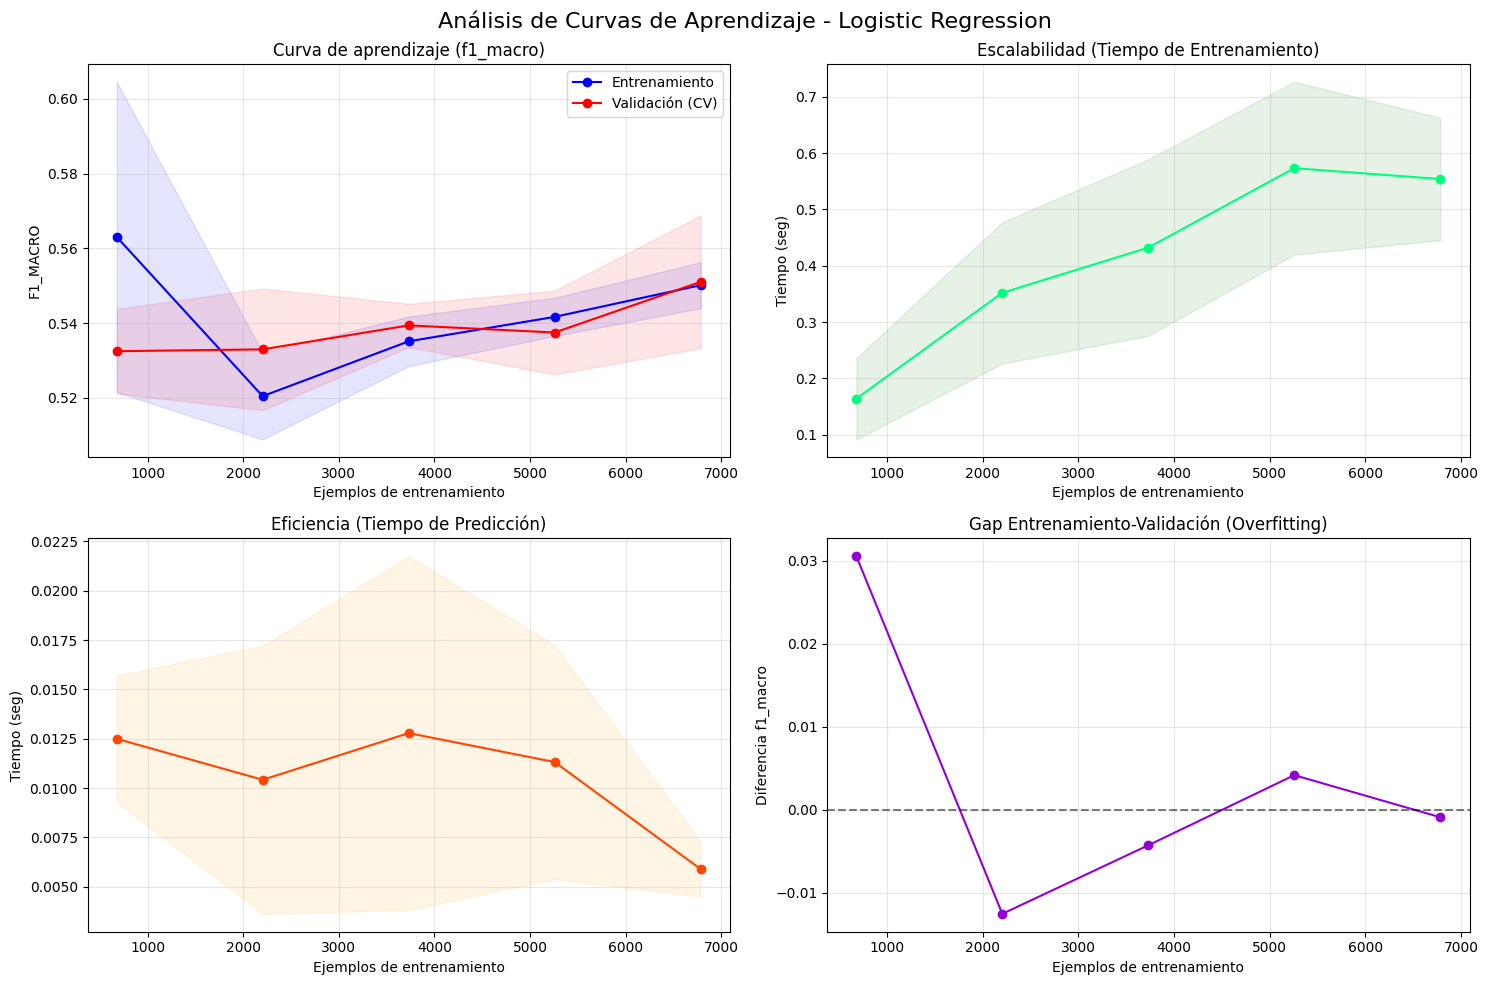


Generando dashboard para Logistic Regression...

MÉTRICAS PROBABILÍSTICAS (TEST)
----------------------------------------
ROC-AUC        : 0.7037
PR-AUC         : 0.9781
Brier Score    : 0.0762
Log Loss       : 0.2976


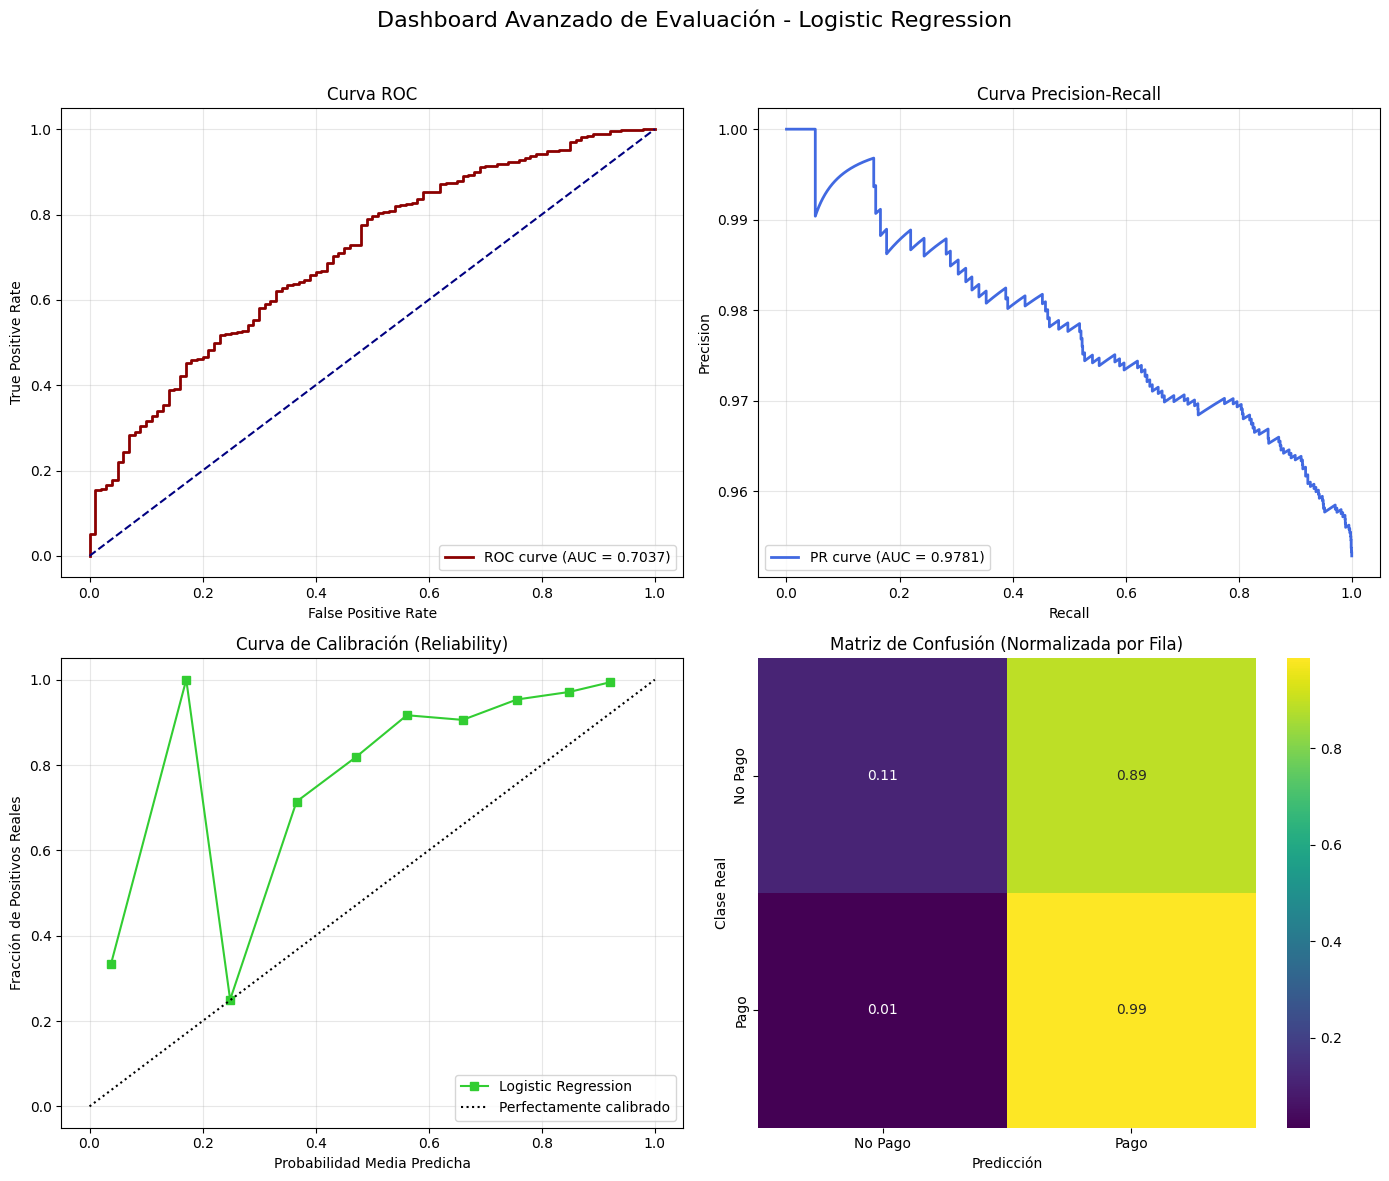



********************************************************************************
INICIANDO OPTIMIZACIÓN Y EVALUACIÓN PARA: Decision Tree
********************************************************************************
Mejor F1-Macro de Optuna: 0.5122
Mejores Hiperparámetros: {'max_depth': 6, 'min_samples_split': 40, 'min_samples_leaf': 15, 'criterion': 'entropy', 'class_weight': None}

EVALUACIÓN Y ANÁLISIS: DECISION TREE

RESUMEN VALIDACIÓN CRUZADA (Train)
------------------------------------------------------------
f1_macro       : 0.5122 ± 0.0114
recall_0       : 0.0500 ± 0.0508
precision_0    : 0.1836 ± 0.1105
f1_0           : 0.0584 ± 0.0312
recall_1       : 0.9787 ± 0.0349
precision_1    : 0.9542 ± 0.0010
f1_1           : 0.9660 ± 0.0171

=== CLASSIFICATION REPORT SOBRE TEST ===
              precision    recall  f1-score   support

 No Pago (0)       0.00      0.00      0.00       100
    Pago (1)       0.95      1.00      0.98      2021

    accuracy                          

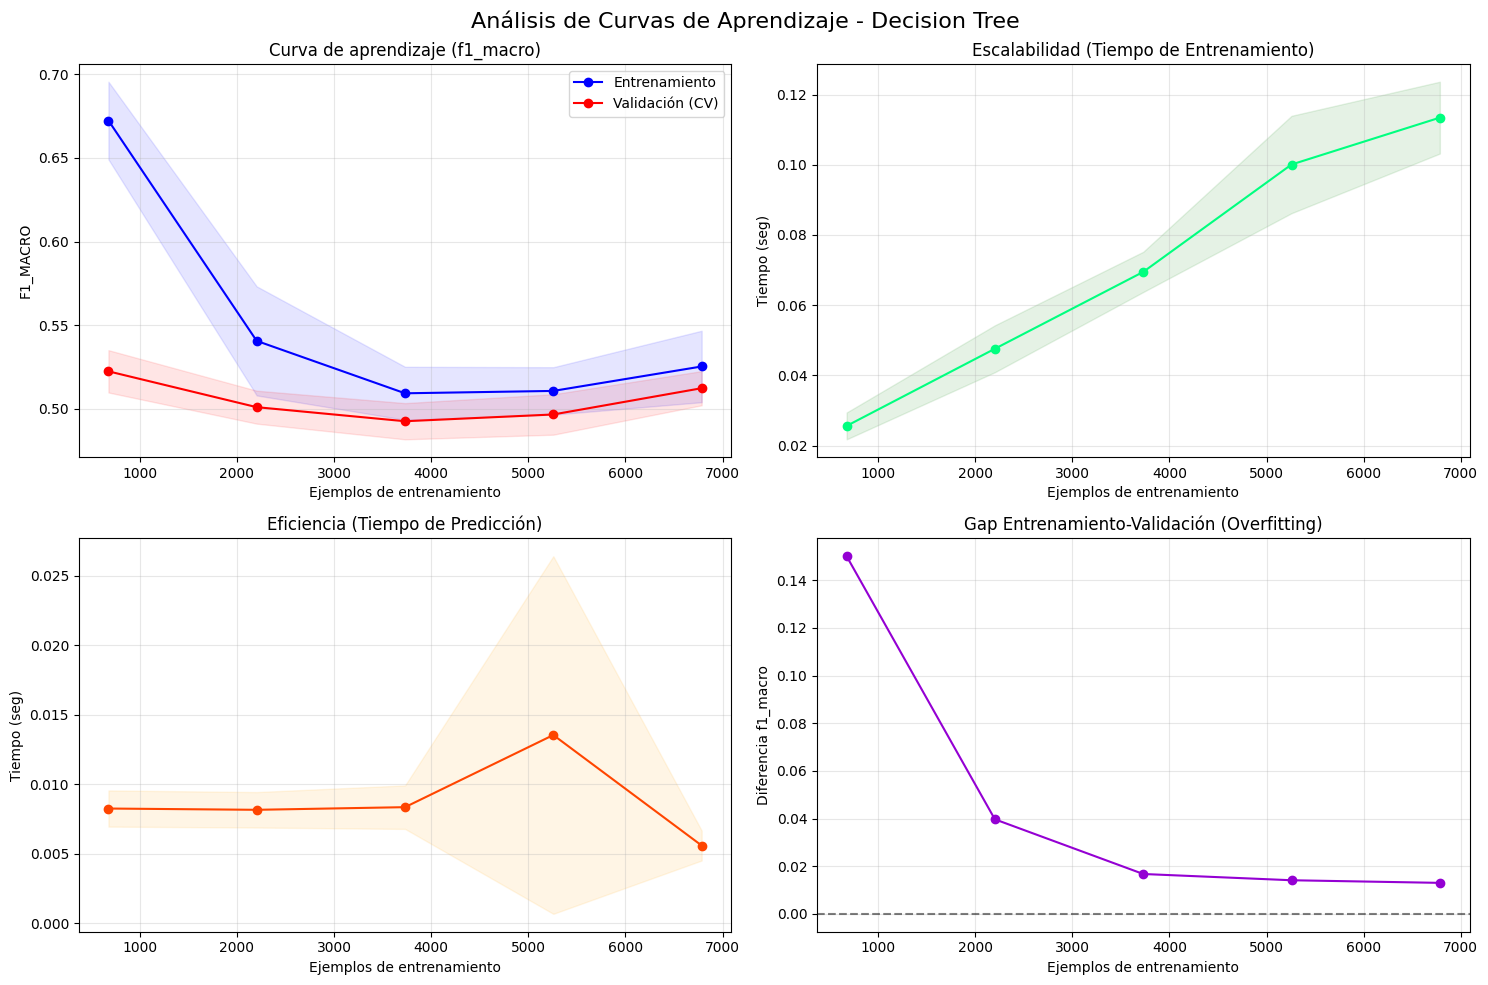


Generando dashboard para Decision Tree...

MÉTRICAS PROBABILÍSTICAS (TEST)
----------------------------------------
ROC-AUC        : 0.6020
PR-AUC         : 0.9630
Brier Score    : 0.0685
Log Loss       : 0.2701


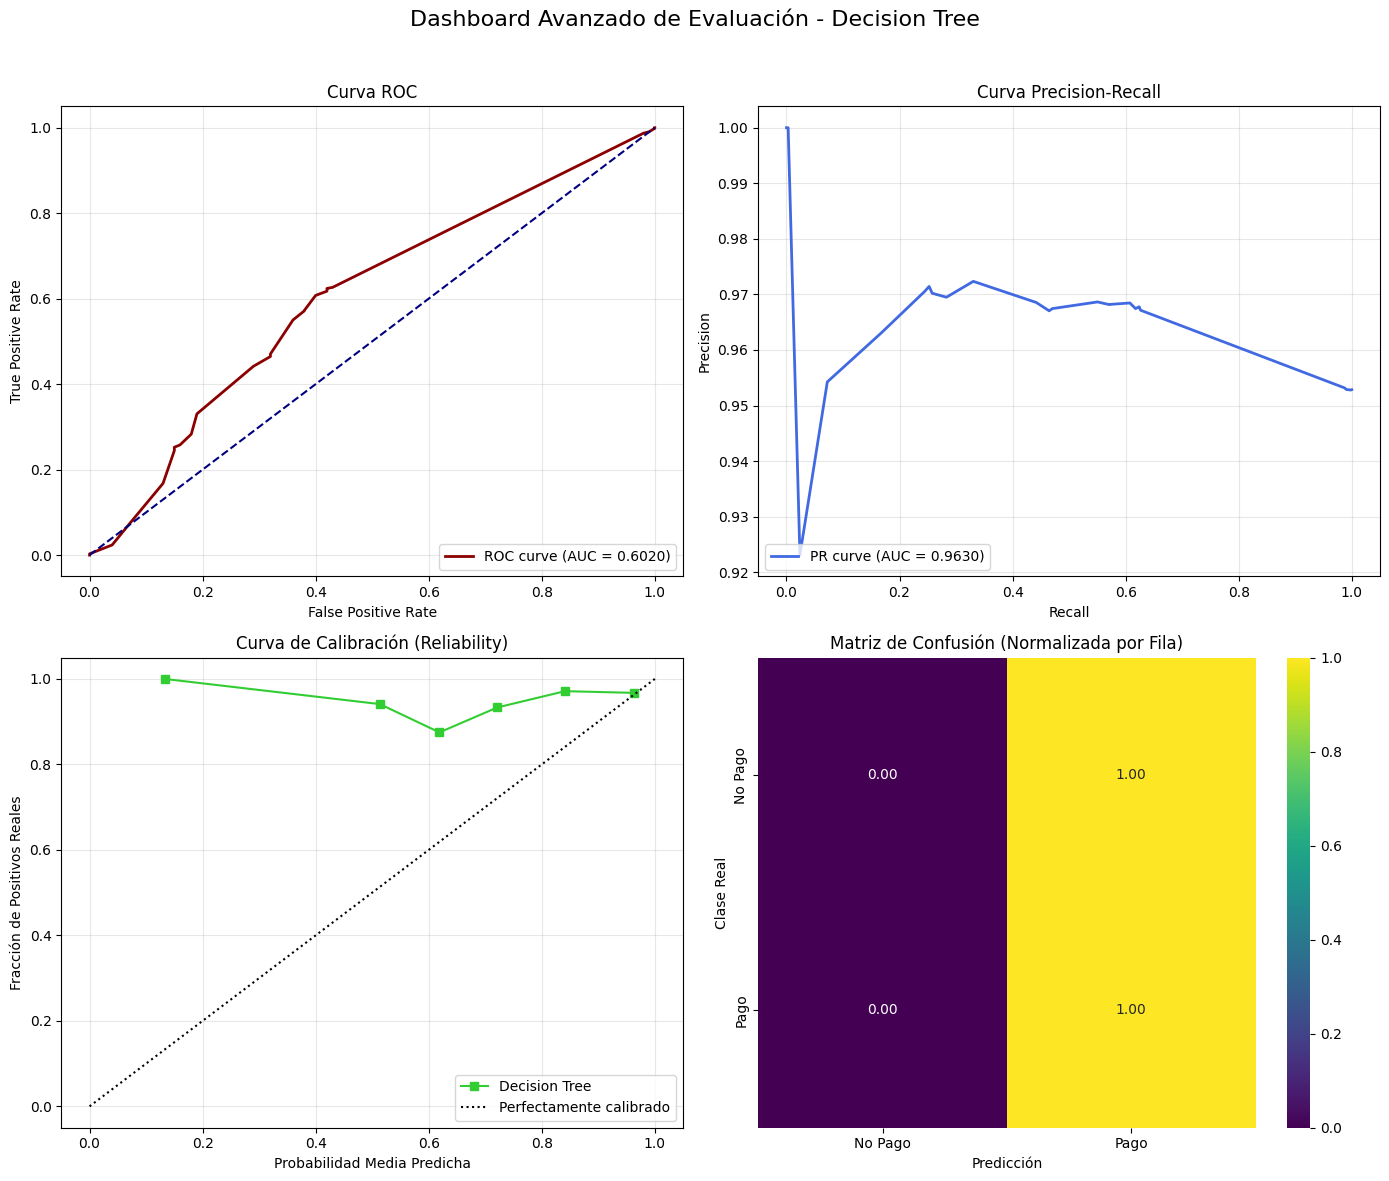



********************************************************************************
INICIANDO OPTIMIZACIÓN Y EVALUACIÓN PARA: Random Forest
********************************************************************************
Mejor F1-Macro de Optuna: 0.55
Mejores Hiperparámetros: {'n_estimators': 75, 'max_depth': 15, 'min_samples_leaf': 14, 'min_samples_split': 50, 'class_weight': 'balanced'}

EVALUACIÓN Y ANÁLISIS: RANDOM FOREST

RESUMEN VALIDACIÓN CRUZADA (Train)
------------------------------------------------------------
f1_macro       : 0.5453 ± 0.0105
recall_0       : 0.2100 ± 0.0526
precision_0    : 0.1173 ± 0.0139
f1_0           : 0.1499 ± 0.0247
recall_1       : 0.9228 ± 0.0105
precision_1    : 0.9594 ± 0.0022
f1_1           : 0.9407 ± 0.0045

=== CLASSIFICATION REPORT SOBRE TEST ===
              precision    recall  f1-score   support

 No Pago (0)       0.11      0.24      0.15       100
    Pago (1)       0.96      0.91      0.93      2021

    accuracy                         

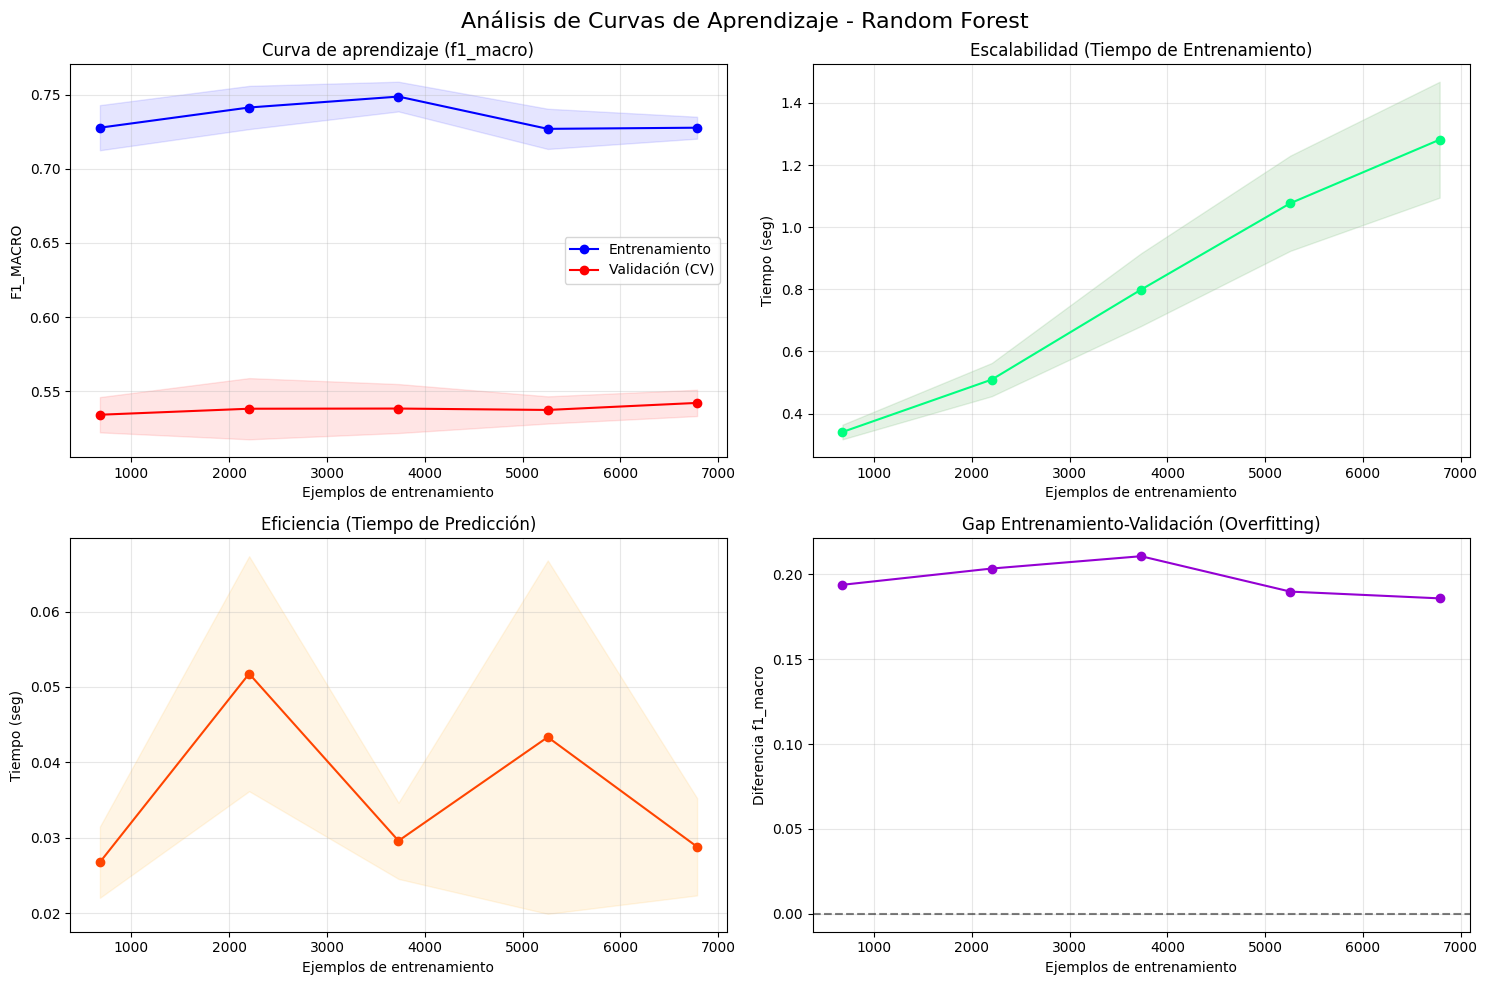


Generando dashboard para Random Forest...

MÉTRICAS PROBABILÍSTICAS (TEST)
----------------------------------------
ROC-AUC        : 0.6710
PR-AUC         : 0.9755
Brier Score    : 0.1185
Log Loss       : 0.3957


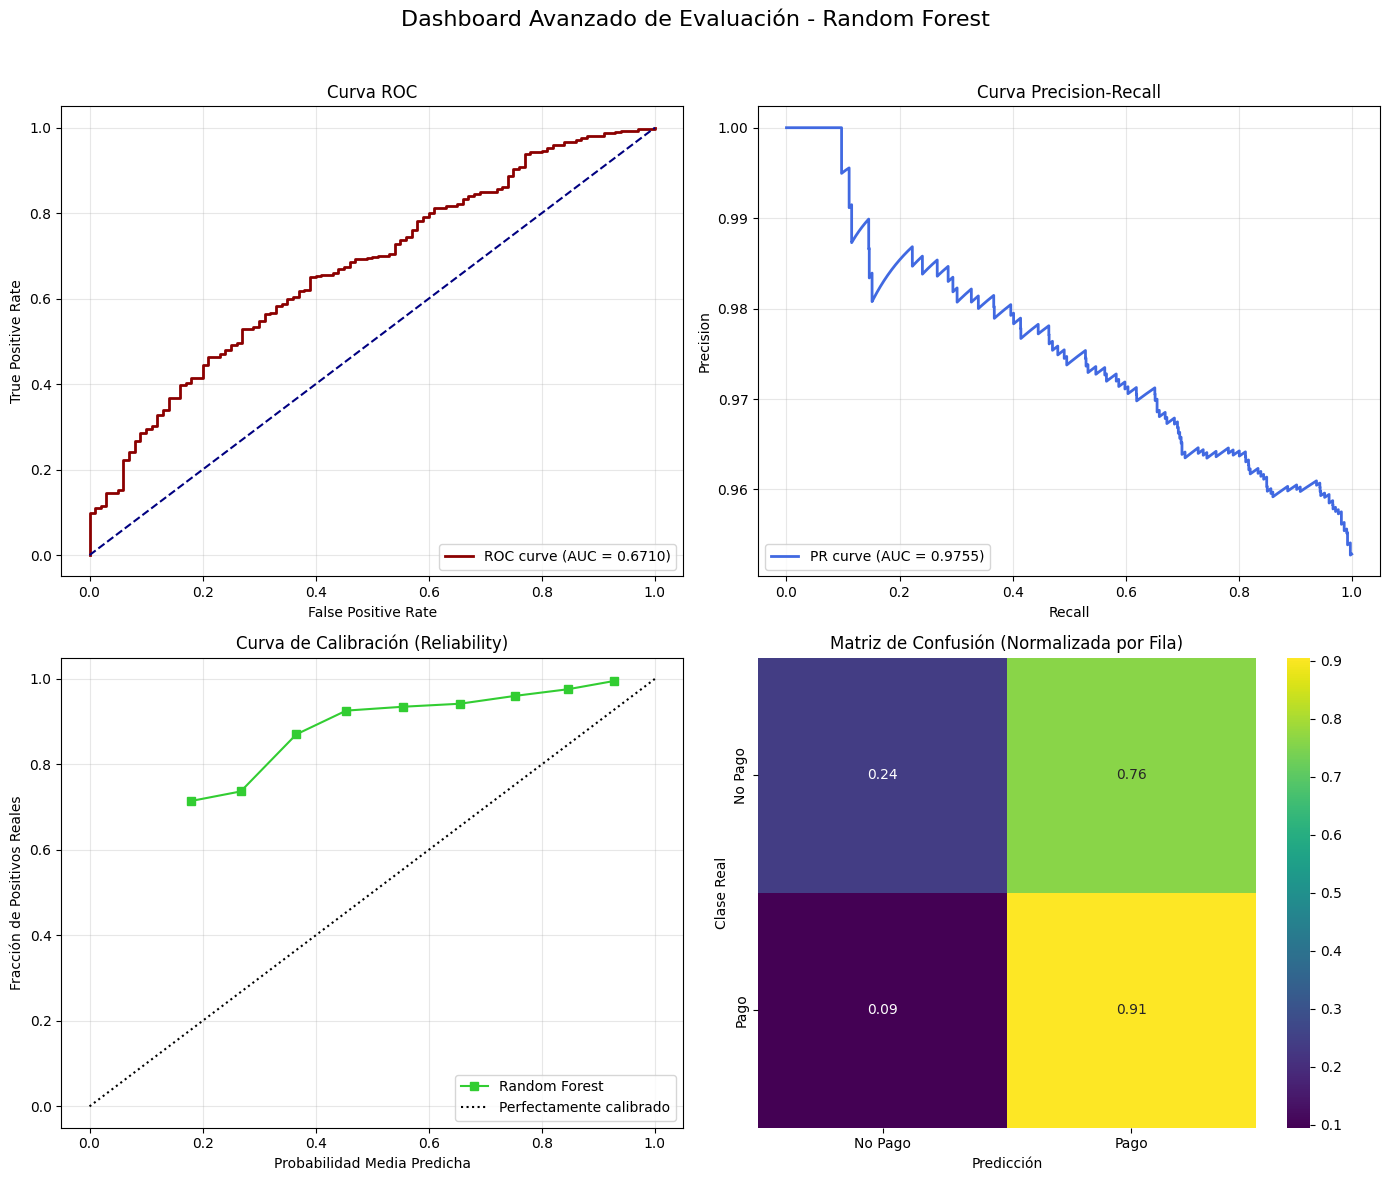



********************************************************************************
INICIANDO OPTIMIZACIÓN Y EVALUACIÓN PARA: XGBoost
********************************************************************************
Mejor F1-Macro de Optuna: 0.5211
Mejores Hiperparámetros: {'n_estimators': 80, 'max_depth': 5, 'learning_rate': 0.0931853893090336, 'subsample': 0.9967929663538303}

EVALUACIÓN Y ANÁLISIS: XGBOOST

RESUMEN VALIDACIÓN CRUZADA (Train)
------------------------------------------------------------
f1_macro       : 0.5185 ± 0.0197
recall_0       : 0.0350 ± 0.0224
precision_0    : 0.2945 ± 0.1450
f1_0           : 0.0622 ± 0.0390
recall_1       : 0.9962 ± 0.0014
precision_1    : 0.9542 ± 0.0010
f1_1           : 0.9748 ± 0.0008

=== CLASSIFICATION REPORT SOBRE TEST ===
              precision    recall  f1-score   support

 No Pago (0)       0.46      0.06      0.11       100
    Pago (1)       0.96      1.00      0.98      2021

    accuracy                           0.95      2121
 

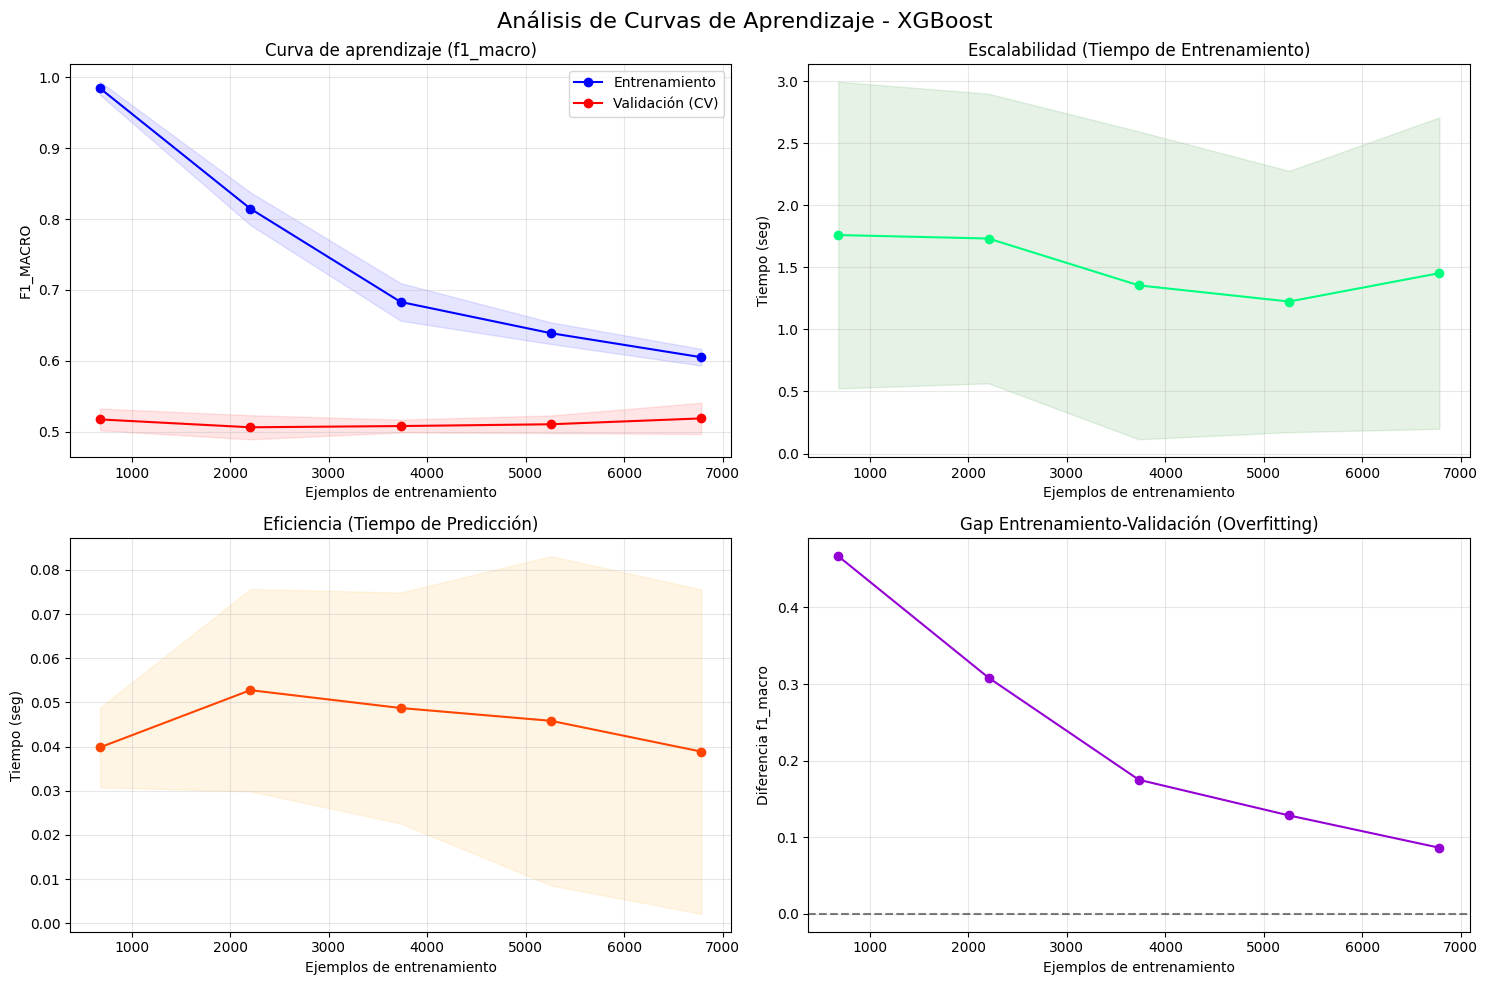


Generando dashboard para XGBoost...

MÉTRICAS PROBABILÍSTICAS (TEST)
----------------------------------------
ROC-AUC        : 0.6602
PR-AUC         : 0.9737
Brier Score    : 0.0513
Log Loss       : 0.2104


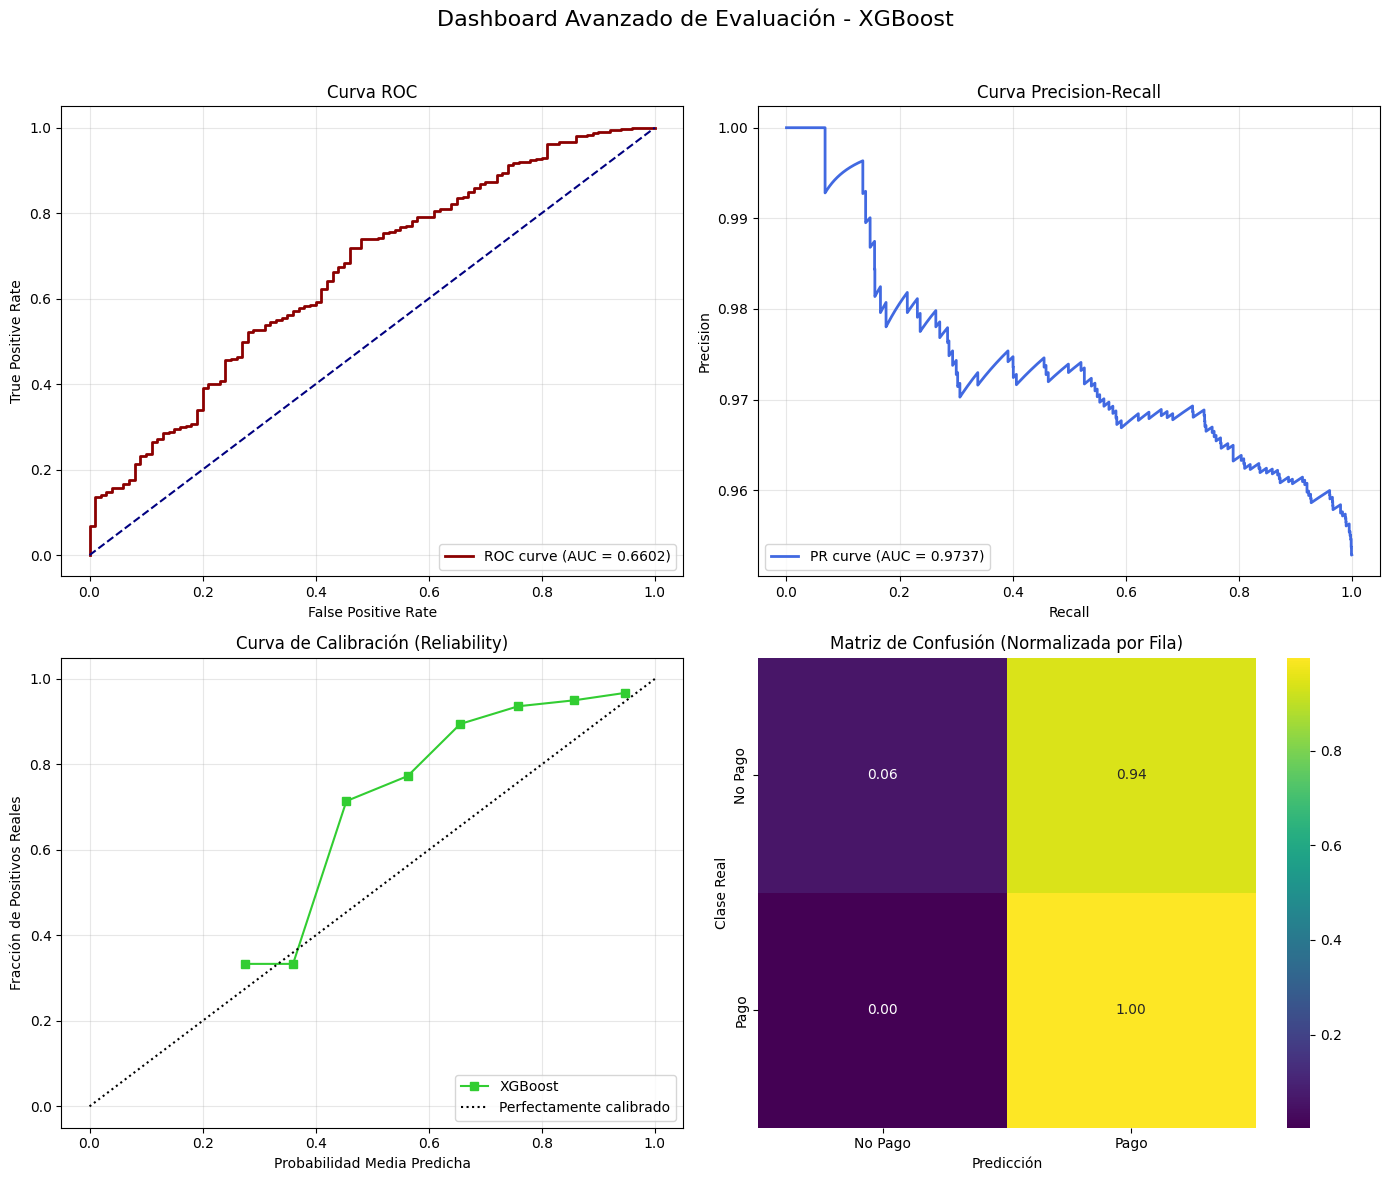



********************************************************************************
INICIANDO OPTIMIZACIÓN Y EVALUACIÓN PARA: LightGBM
********************************************************************************
Mejor F1-Macro de Optuna: 0.5223
Mejores Hiperparámetros: {'n_estimators': 125, 'max_depth': 6, 'learning_rate': 0.08104930202422957, 'num_leaves': 25, 'subsample': 0.724685397227146, 'colsample_bytree': 0.6279440537702727}

EVALUACIÓN Y ANÁLISIS: LIGHTGBM

RESUMEN VALIDACIÓN CRUZADA (Train)
------------------------------------------------------------
f1_macro       : 0.5201 ± 0.0187
recall_0       : 0.0350 ± 0.0205
precision_0    : 0.4956 ± 0.2122
f1_0           : 0.0646 ± 0.0370
recall_1       : 0.9980 ± 0.0015
precision_1    : 0.9543 ± 0.0009
f1_1           : 0.9757 ± 0.0009

=== CLASSIFICATION REPORT SOBRE TEST ===
              precision    recall  f1-score   support

 No Pago (0)       0.42      0.05      0.09       100
    Pago (1)       0.95      1.00      0.98      

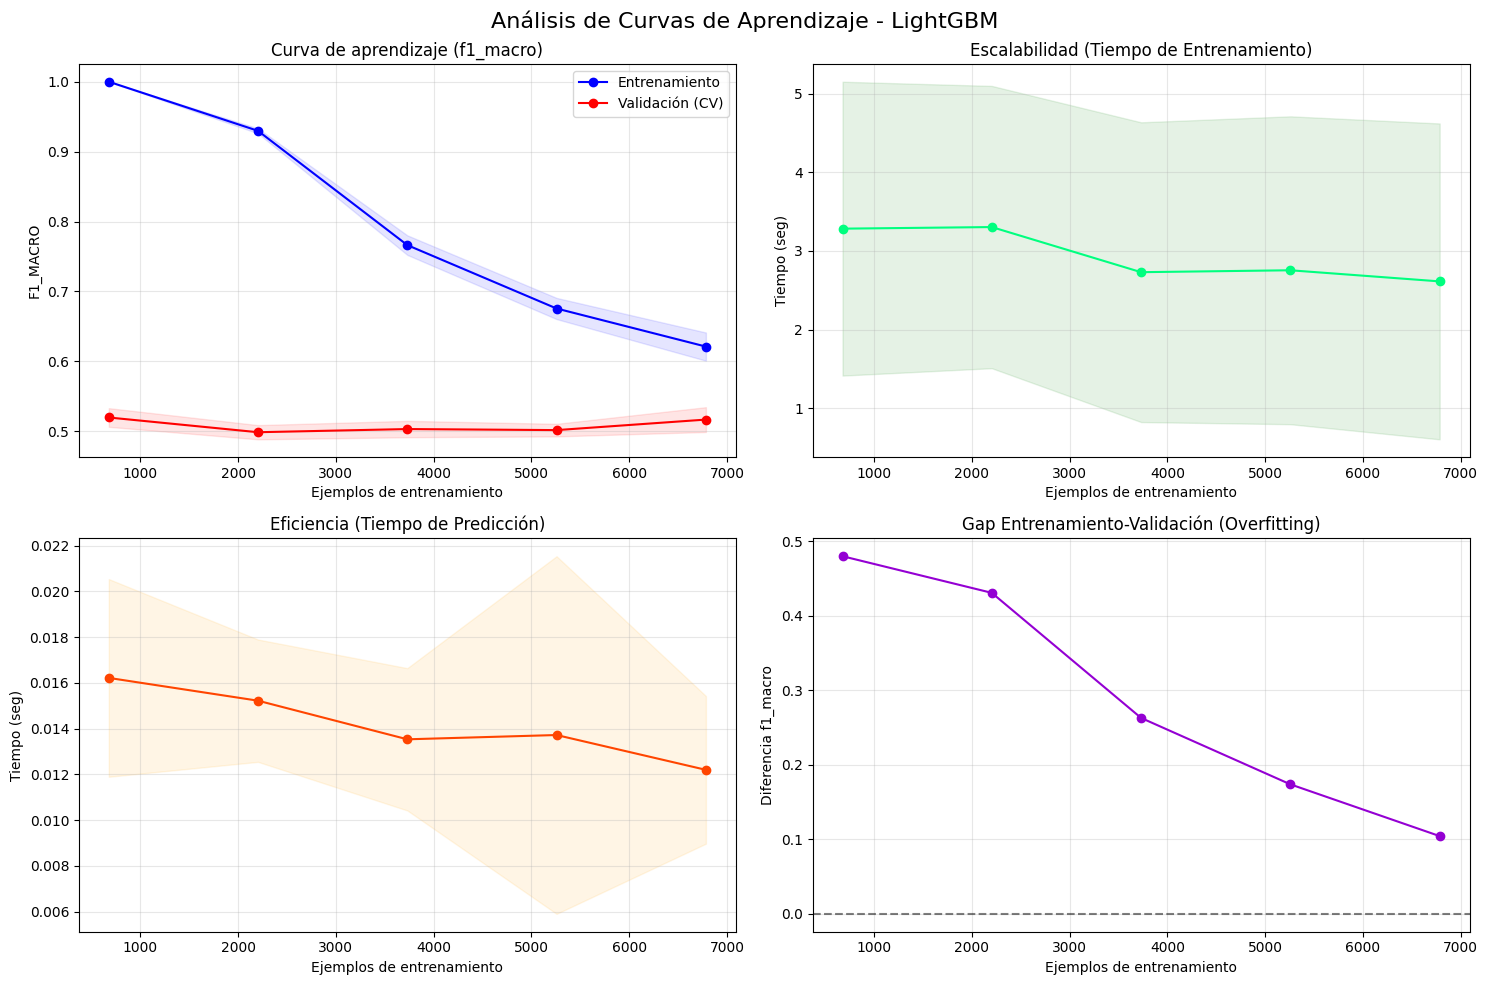


Generando dashboard para LightGBM...

MÉTRICAS PROBABILÍSTICAS (TEST)
----------------------------------------
ROC-AUC        : 0.6493
PR-AUC         : 0.9700
Brier Score    : 0.0476
Log Loss       : 0.1978


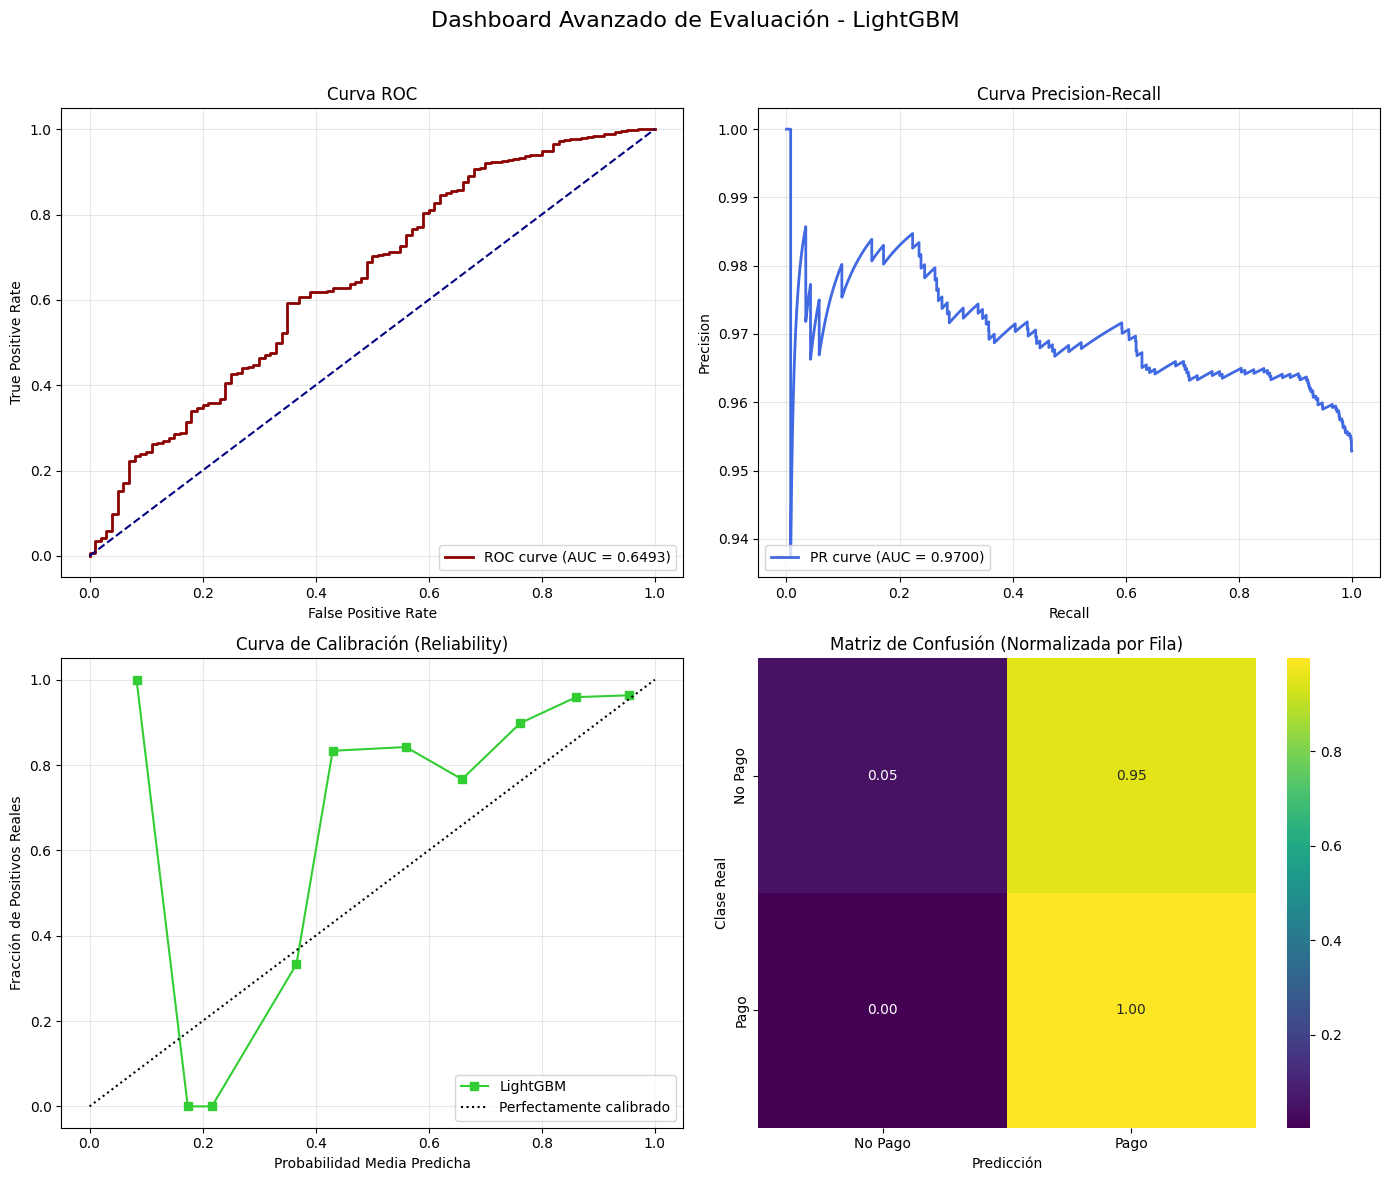



********************************************************************************
INICIANDO OPTIMIZACIÓN Y EVALUACIÓN PARA: SVM
********************************************************************************
Mejor F1-Macro de Optuna: 0.5221
Mejores Hiperparámetros: {'kernel': 'rbf', 'gamma': 0.08455142508090772}

EVALUACIÓN Y ANÁLISIS: SVM

RESUMEN VALIDACIÓN CRUZADA (Train)
------------------------------------------------------------
f1_macro       : 0.5221 ± 0.0208
recall_0       : 0.0425 ± 0.0288
precision_0    : 0.2533 ± 0.1165
f1_0           : 0.0705 ± 0.0423
recall_1       : 0.9938 ± 0.0037
precision_1    : 0.9545 ± 0.0012
f1_1           : 0.9737 ± 0.0014

=== CLASSIFICATION REPORT SOBRE TEST ===
              precision    recall  f1-score   support

 No Pago (0)       0.26      0.05      0.08       100
    Pago (1)       0.95      0.99      0.97      2021

    accuracy                           0.95      2121
   macro avg       0.61      0.52      0.53      2121
weighted avg  

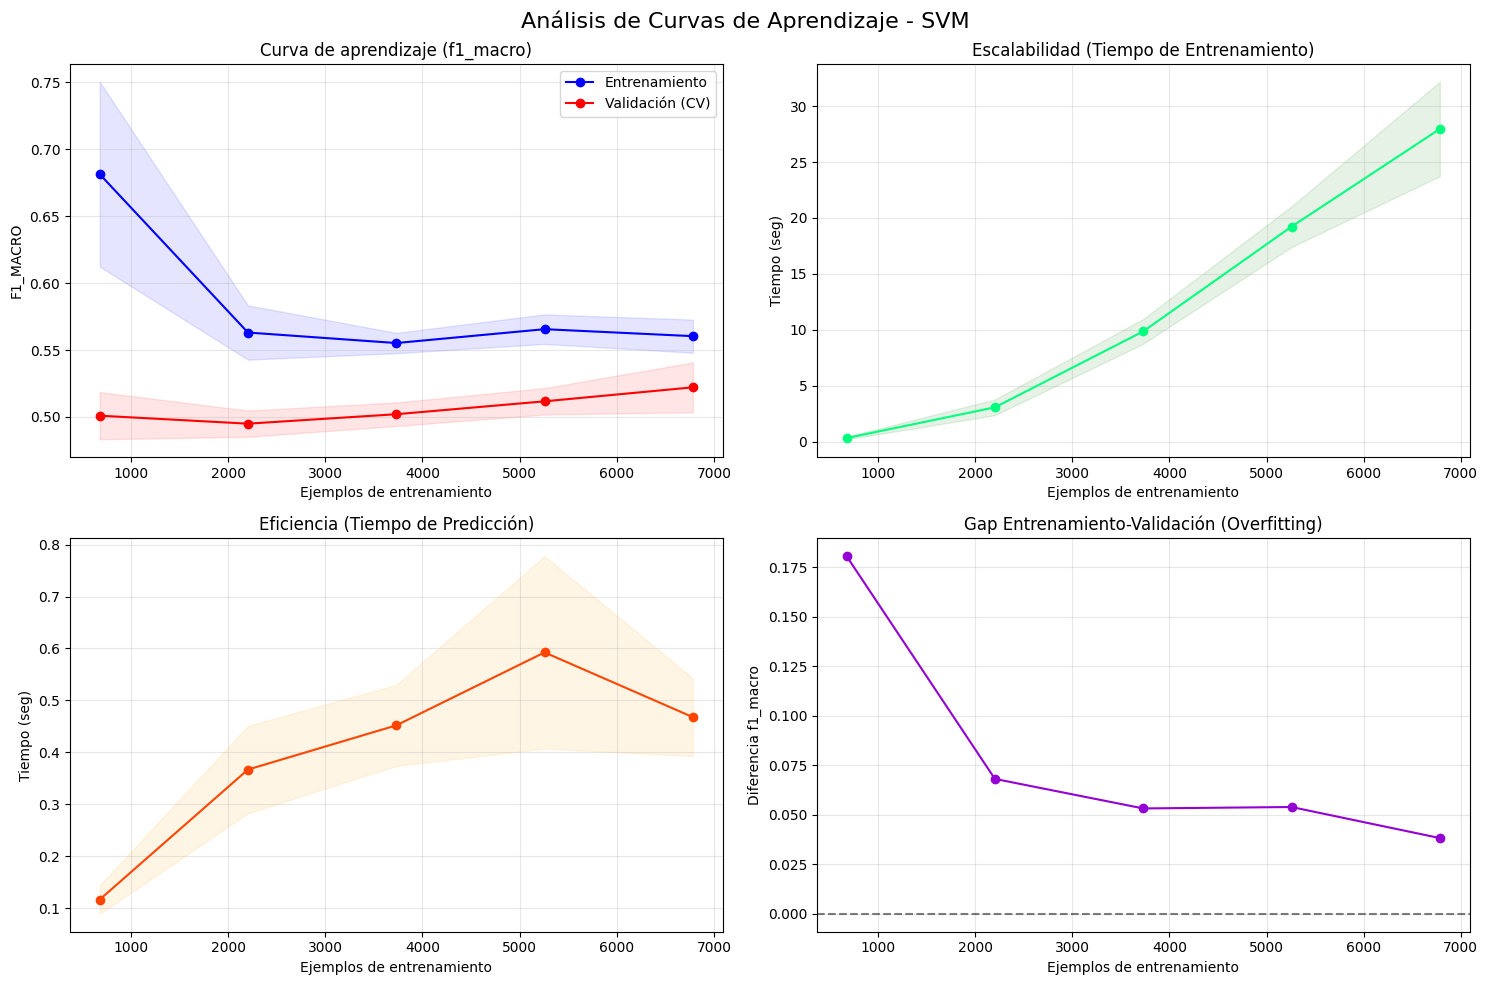


Generando dashboard para SVM...

MÉTRICAS PROBABILÍSTICAS (TEST)
----------------------------------------
ROC-AUC        : 0.6357
PR-AUC         : 0.9635
Brier Score    : 0.0688
Log Loss       : 0.2834


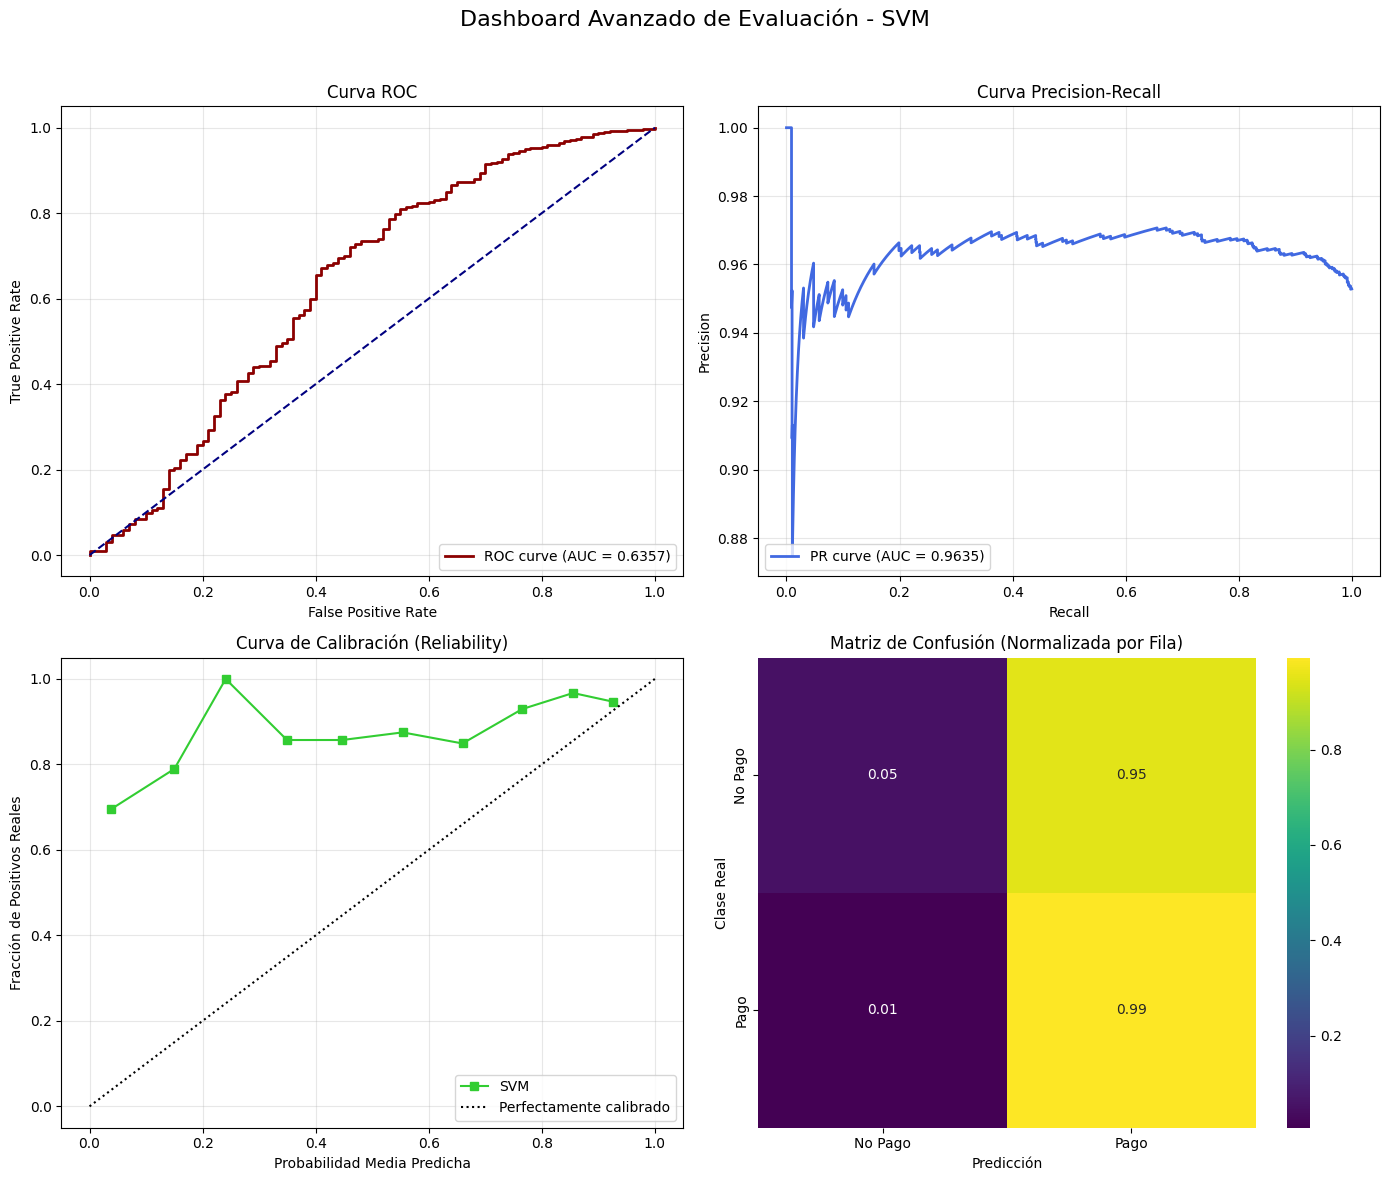

In [8]:
# -------------------------------------------------------------------------------------------------
# 4. BUCLE DE EJECUCIÓN
# -------------------------------------------------------------------------------------------------


modelos_clasificadores = {
    'Logistic Regression': (logistic_regression_tuning, LogisticRegression),
    'Decision Tree': (decision_tree_tuning, DecisionTreeClassifier),
    'Random Forest': (random_forest_tuning, RandomForestClassifier),
    'XGBoost': (xgboost_tuning, XGBClassifier),
    'LightGBM': (lightGBM_tuning, LGBMClassifier),
    'SVM': (svm_tuning, SVC),
}

for name, (objective, constructor) in modelos_clasificadores.items():

    print(f"\n\n{'*'*80}")
    print(f"INICIANDO OPTIMIZACIÓN Y EVALUACIÓN PARA: {name}")
    print(f"{'*'*80}")


    # 1. Ejecutar Optuna y sus estudios

    study = optuna.create_study(direction = 'maximize')
    study.optimize(objective, n_trials = 20)  

    print(f"Mejor F1-Macro de Optuna: {round(study.best_value, 4)}")
    print(f"Mejores Hiperparámetros: {study.best_params}")


    # 2. Construir el modelo ganador (Si es SVM se deben activar las probabilidades de la clase)

    best_params = study.best_params.copy()

    if name == 'SVM':

        best_params['probability'] = True  

    best_base_model = constructor(**best_params)

    final_pipeline = Pipeline(steps = [
        ('smote', SMOTE(sampling_strategy = SMOTE_RATIO, random_state = 42)),
        ('model', best_base_model)
    ])


    # 3. Evaluar y Analizar Estabilidad

    cv_detailed, test_f1 = evaluate_and_analyze(
        pipeline_model = final_pipeline,
        X_train = X_train, y_train = y_train,
        X_test = X_test, y_test = y_test,
        model_name = name
    )


    # 4. Generar Curvas de Aprendizaje (Overfitting/Escalabilidad)

    plot_learning_curves(
        estimator = final_pipeline,
        X = X_train, y = y_train,
        scoring = "f1_macro",
        model_name = name
    )


    # 5. Generar Dashboard Avanzado (Probabilidades)

    plot_advanced_evaluation(pipeline_model = final_pipeline, X_test = X_test, y_test = y_test, model_name = name)


    # 6. Guardar resultados
    
    resultados_modelos[name] = {
        'model': final_pipeline,
        'parameters': study.best_params,
        'test_f1_macro': test_f1,
        'study': study
    }

In [ ]:
# Guardar modelos finalistas


# Cargar Environment

load_dotenv()

ruta_guardado = Path(os.getenv("ARTIFACTS"))

os.makedirs(ruta_guardado, exist_ok = True)


# Vamos a guardar 4 modelos

modelos_finalistas = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

for nombre in modelos_finalistas:

    if nombre in resultados_modelos:

        modelo_pipeline = resultados_modelos[nombre]['model']
        
        nombre_archivo = f"{nombre.replace(' ', '_')}_final.pkl"
        ruta_completa = os.path.join(ruta_guardado, nombre_archivo)
        
        with open(ruta_completa, 'wb') as archivo:

            pickle.dump(modelo_pipeline, archivo)
            
        print(f"Modelo guardado exitosamente")

    else:

        print(f"Error")

Modelo guardado exitosamente
Modelo guardado exitosamente
Modelo guardado exitosamente
Modelo guardado exitosamente


# Optimización del Umbral de Decisión de SKLearn

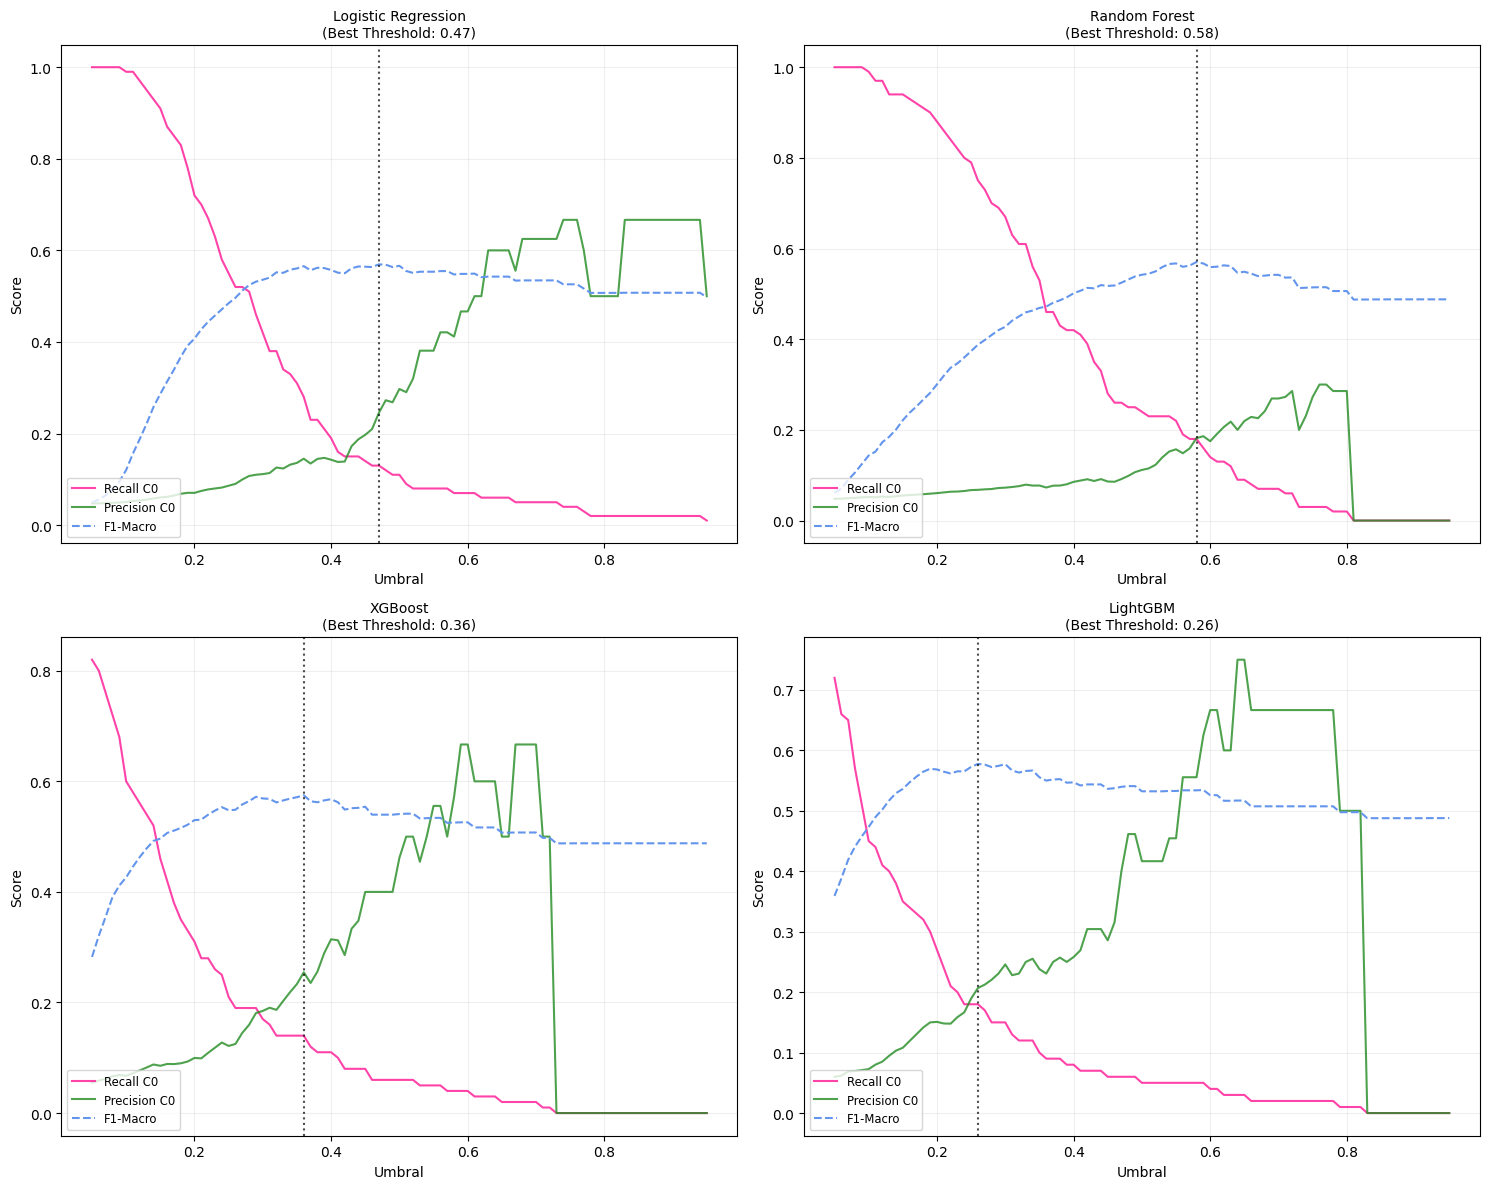

In [10]:
# Función para calcular me´tricas y poner el umbral para cada modelo

def optimizar_y_graficar_umbral(modelo_pipeline, X_test, y_test, nombre_modelo, ax):


    # 1. Obtener probabilidades de Clase 0 (que son los morososs)

    proba_clase_0 = modelo_pipeline.predict_proba(X_test)[:, 0]
    

    # 2. Definir umbrales

    umbrales = np.linspace(0.05, 0.95, 91)

    recalls, precisions, f1_macros = [], [], []
    

    # 3. Evaluar

    for t in umbrales:

        y_pred_simulada = np.where(proba_clase_0 >= t, 0, 1)
        recalls.append(recall_score(y_test, y_pred_simulada, pos_label = 0, zero_division = 0))
        precisions.append(precision_score(y_test, y_pred_simulada, pos_label = 0, zero_division = 0))
        f1_macros.append(f1_score(y_test, y_pred_simulada, average = 'macro'))
        
    mejor_idx = np.argmax(f1_macros)
    mejor_umbral = umbrales[mejor_idx]
    
    # 4. Graficar 

    ax.plot(umbrales, recalls, label = 'Recall C0', color = 'deeppink', alpha = 0.8)
    ax.plot(umbrales, precisions, label = 'Precision C0', color = 'forestgreen', alpha = 0.8)
    ax.plot(umbrales, f1_macros, label = 'F1-Macro', color = 'cornflowerblue', linestyle = '--')
    
    ax.axvline(x = mejor_umbral, color = 'black', linestyle = ':', alpha = 0.7)
    ax.set_title(f'{nombre_modelo}\n(Best Threshold: {mejor_umbral:.2f})', fontsize = 10)
    ax.set_xlabel('Umbral')
    ax.set_ylabel('Score')
    ax.legend(fontsize = 'small', loc = 'lower left')
    ax.grid(alpha = 0.2)

# Ejecución

modelos_finalistas = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(2, 2, figsize = (15, 12))

axes = axes.flatten()  

for i, nombre in enumerate(modelos_finalistas):

    modelo_actual = resultados_modelos[nombre]['model']
    
    optimizar_y_graficar_umbral(
        modelo_pipeline = modelo_actual,
        X_test = X_test,
        y_test = y_test,
        nombre_modelo = nombre,
        ax = axes[i]
    )

plt.tight_layout()
plt.show()